![image.png](https://i.imgur.com/a3uAqnb.png)

# Image Captioning ! (using attention)

Image captioning combines computer vision and sequence generation:

```text
Image → CNN Encoder → Attention context vector → LSTM Decoder → Caption
```

The model will learn to generate captions word by word.  
At each word, the attention mechanism learns which image regions are most relevant.

## Image Captioning Architecture

The image-captioning model has three main parts:

| Component | Role |
|---|---|
| **CNN Encoder** | Extracts spatial image features from the image |
| **Attention Layer** | Selects the most relevant image regions at each decoding step |
| **LSTM Decoder** | Generates the caption word by word |

The attention mechanism is useful because different words may depend on different parts of the image.

Example:

| Generated word | Region the model may attend to |
|---|---|
| `dog` | the dog region |
| `running` | the body/legs region |
| `grass` | the ground region |

So instead of using one fixed image vector for the whole caption, the model can focus on different visual regions during generation.

In [ ]:
# Install KaggleHub if needed
!pip install -q kagglehub

In [ ]:
import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Download Flickr8k Dataset


In [ ]:


dataset_handles = [
    "srinivasac/flickr8k-dataset",
    "adityajn105/flickr8k"
]

flickr_path = None

for handle in dataset_handles:
    try:
        print(f"Trying dataset: {handle}")
        flickr_path = kagglehub.dataset_download(handle)
        print("Downloaded successfully.")
        break
    except Exception as error:
        print(f"Could not download {handle}: {error}")

if flickr_path is None:
    raise RuntimeError("Could not download Flickr8k. Check KaggleHub login or dataset access.")

print("\nDataset path:")
print(flickr_path)

Trying dataset: srinivasac/flickr8k-dataset


100%|██████████| 1.04G/1.04G [00:11<00:00, 100MB/s]

Extracting files...


Downloaded successfully.

Dataset path:
/root/.cache/kagglehub/datasets/srinivasac/flickr8k-dataset/versions/1


In [ ]:
# Find image files and caption file automatically

image_extensions = (".jpg", ".jpeg", ".png")
image_files = []
caption_candidates = []

for root, dirs, files in os.walk(flickr_path):
    for file in files:
        full_path = os.path.join(root, file)

        if file.lower().endswith(image_extensions):
            image_files.append(full_path)

        if file.lower() in ["captions.txt", "flickr8k.token.txt"] or "caption" in file.lower():
            caption_candidates.append(full_path)

print("Number of image files found:", len(image_files))
print("\nCaption file candidates:")
for file in caption_candidates:
    print(file)

if len(image_files) == 0:
    raise RuntimeError("No image files found. Please inspect the dataset folder.")

if len(caption_candidates) == 0:
    raise RuntimeError("No caption file found. Please inspect the dataset folder.")

# Use the first caption file candidate
captions_file = caption_candidates[0]

# Map image filename to full path
image_paths = {
    os.path.basename(path): path
    for path in image_files
}

print("\nUsing caption file:")
print(captions_file)

Number of image files found: 8091

Caption file candidates:
/root/.cache/kagglehub/datasets/srinivasac/flickr8k-dataset/versions/1/flickr8k/captions.txt

Using caption file:
/root/.cache/kagglehub/datasets/srinivasac/flickr8k-dataset/versions/1/flickr8k/captions.txt


In [ ]:
def load_flickr_captions(captions_file):
    # Load Flickr8k captions from common formats:
    # 1. captions.txt with columns: image, caption
    # 2. Flickr8k.token.txt with rows: image.jpg#0<TAB>caption

    filename = os.path.basename(captions_file).lower()

    if filename == "flickr8k.token.txt":
        rows = []

        with open(captions_file, "r", encoding="utf-8", errors="ignore") as file:
            for line in file:
                line = line.strip()

                if "\t" not in line:
                    continue

                image_id, caption = line.split("\t", 1)
                image_name = image_id.split("#")[0]

                rows.append({
                    "image": image_name,
                    "caption": caption
                })

        return pd.DataFrame(rows)

    # Most Kaggle versions use a CSV-like captions.txt file
    df_captions = pd.read_csv(captions_file)

    # Normalize column names
    df_captions.columns = [col.strip().lower() for col in df_captions.columns]

    if "image" not in df_captions.columns:
        df_captions = df_captions.rename(columns={df_captions.columns[0]: "image"})

    if "caption" not in df_captions.columns:
        df_captions = df_captions.rename(columns={df_captions.columns[1]: "caption"})

    return df_captions[["image", "caption"]]


captions_df = load_flickr_captions(captions_file)

# Keep only captions whose images are available
captions_df = captions_df[captions_df["image"].isin(image_paths)].copy()
captions_df = captions_df.dropna().reset_index(drop=True)

print("Captions shape:", captions_df.shape)
print("Unique images:", captions_df["image"].nunique())
display(captions_df.head())

Captions shape: (40455, 2)
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## Dataset Statistics

Before training, we inspect the image-captioning dataset.

Important checks:

- number of images
- number of captions
- captions per image
- caption length distribution

Number of captions: 40455
Number of unique images: 8091

Captions per image:
count    8091.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
dtype: float64

Caption length statistics:
count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_word_count, dtype: float64


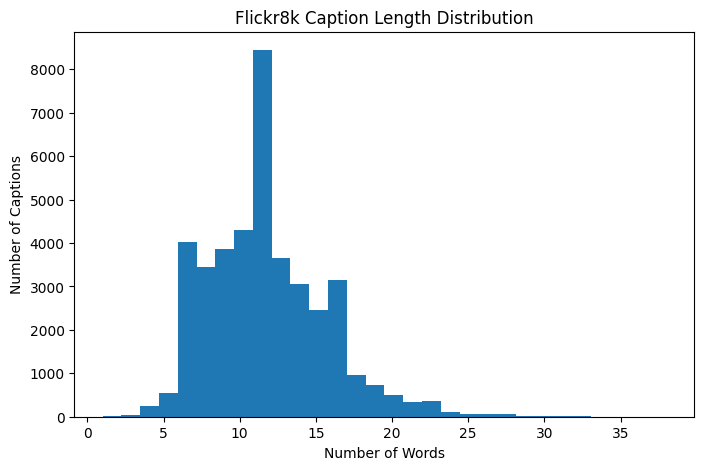

In [ ]:
captions_df["caption_word_count"] = captions_df["caption"].apply(lambda x: len(str(x).split()))

print("Number of captions:", len(captions_df))
print("Number of unique images:", captions_df["image"].nunique())

print("\nCaptions per image:")
print(captions_df.groupby("image").size().describe())

print("\nCaption length statistics:")
print(captions_df["caption_word_count"].describe())

plt.figure(figsize=(8, 5))
captions_df["caption_word_count"].plot(kind="hist", bins=30)
plt.title("Flickr8k Caption Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Captions")
plt.show()

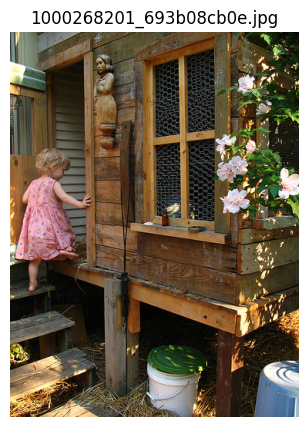

Captions:
1. A child in a pink dress is climbing up a set of stairs in an entry way .
2. A girl going into a wooden building .
3. A little girl climbing into a wooden playhouse .
4. A little girl climbing the stairs to her playhouse .
5. A little girl in a pink dress going into a wooden cabin .


In [ ]:
# Show one image with its captions

sample_image_name = captions_df["image"].iloc[0]
sample_image_path = image_paths[sample_image_name]

sample_captions = captions_df[captions_df["image"] == sample_image_name]["caption"].tolist()

image = Image.open(sample_image_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(sample_image_name)
plt.show()

print("Captions:")
for i, caption in enumerate(sample_captions, start=1):
    print(f"{i}. {caption}")

## Prepare a Small Training Subset

Image captioning can be computationally expensive.

I've trained the model using all images, but if you'd like you can use a subset of the images for faster prototyping and messin' around with it!

In [ ]:

MAX_IMAGES = len(captions_df) #1000

unique_images = captions_df["image"].unique().tolist()
random.shuffle(unique_images)

selected_images = unique_images[:MAX_IMAGES]

small_captions_df = captions_df[captions_df["image"].isin(selected_images)].copy()
small_captions_df = small_captions_df.reset_index(drop=True)

print("Selected images:", small_captions_df["image"].nunique())
print("Selected captions:", len(small_captions_df))
display(small_captions_df.head())

Selected images: 8091
Selected captions: 40455


,image,caption,caption_word_count
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,18
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,8
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,9
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,10
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,13


In [ ]:
unique_images = small_captions_df["image"].unique().tolist()
random.shuffle(unique_images)

split_idx = int(0.8 * len(unique_images))

train_images = set(unique_images[:split_idx])
val_images = set(unique_images[split_idx:])

train_captions_df = small_captions_df[small_captions_df["image"].isin(train_images)].reset_index(drop=True)
val_captions_df = small_captions_df[small_captions_df["image"].isin(val_images)].reset_index(drop=True)

print("Train images:", train_captions_df["image"].nunique())
print("Train captions:", len(train_captions_df))

print("\nValidation images:", val_captions_df["image"].nunique())
print("Validation captions:", len(val_captions_df))

Train images: 6472
Train captions: 32360

Validation images: 1619
Validation captions: 8095


## So how would the decoder .. generate one word ?
well this is actually just a multi-class classification, the decoder just picks the token it thinks is the right word, we can just use cross entropy

- Sure, but how do we know that the generator finished generating ?
well we have the `<END>` token for that, when the generator predicts `<END>` then we know it's finished.

we have other 'utility' tokens to make generation work:
| Token | Purpose |
|---|---|
| `<PAD>` | used for padding shorter captions |
| `<UNK>` | unknown word |
| `<START>` | beginning of a caption |
| `<END>` | end of a caption |

The vocabulary is built from the **training captions only** to avoid data leakage.

In [ ]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
START_TOKEN = "<SOS>"
END_TOKEN = "<END>"

def clean_caption(caption):
    caption = str(caption).lower()
    caption = re.sub(r"[^a-zA-Z\s]", " ", caption)
    caption = re.sub(r"\s+", " ", caption).strip()
    return caption

def tokenize_caption(caption):
    return clean_caption(caption).split()

counter = Counter()

for caption in train_captions_df["caption"]:
    counter.update(tokenize_caption(caption))

MIN_WORD_FREQ = 2

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
    START_TOKEN: 2,
    END_TOKEN: 3
}

for word, freq in counter.items():
    if freq >= MIN_WORD_FREQ:
        vocab[word] = len(vocab)

idx2word = {
    idx: word
    for word, idx in vocab.items()
}

print("Vocabulary size:", len(vocab))
print("Most common words:", counter.most_common(20))

Vocabulary size: 4641
Most common words: [('a', 50396), ('in', 15161), ('the', 14662), ('on', 8597), ('is', 7443), ('and', 7098), ('dog', 6486), ('with', 6262), ('man', 5770), ('of', 5359), ('two', 4570), ('white', 3176), ('black', 3034), ('boy', 2863), ('are', 2792), ('woman', 2726), ('girl', 2712), ('to', 2517), ('wearing', 2388), ('at', 2321)]


### Teacher forcing!
- Question: how come the model's input isn't what it generated ?
shouldn't it generate the first word then we use that word as input to generate the next one ? ❤️ <- random emoji so text looks clean

during training, if the model predicted a word that isn't the correct word, we'll punish the model for it (gradients) but we know that it's a wrong word, so we feed it the correct one to make training faster.   

this is equavaliant to telling a student it got the first part of the question wrong, telling the student the correct answer, and telling it to solve the next part of the question

In [ ]:
MAX_CAPTION_LEN = 25

def encode_caption(caption, vocab, max_len=MAX_CAPTION_LEN):
    # Creates input and target sequences.
    # Example: a picture of our goat TA Ali running, as a normal Ali does
    # caption = "A wild Ali running"
    # input:  <SOS>   A    wild     Ali     running <-- input to the model
    # target:   A    wild   Ali   running    <END>  <-- label, model should predict this
    # before trainning predections (example): in in in in in


    tokens = tokenize_caption(caption)[:max_len]

    token_ids = [
        vocab.get(token, vocab[UNK_TOKEN])
        for token in tokens
    ]

    input_ids = [vocab[START_TOKEN]] + token_ids
    target_ids = token_ids + [vocab[END_TOKEN]]

    return input_ids, target_ids


example_input, example_target = encode_caption(train_captions_df["caption"].iloc[0], vocab)

print("Original caption:")
print(train_captions_df["caption"].iloc[0])

print("\nInput IDs:")
print(example_input)

print("\nTarget IDs:")
print(example_target)

Original caption:
A child in a pink dress is climbing up a set of stairs in an entry way .

Input IDs:
[2, 4, 5, 6, 4, 7, 8, 9, 10, 11, 4, 12, 13, 14, 6, 15, 1, 16]

Target IDs:
[4, 5, 6, 4, 7, 8, 9, 10, 11, 4, 12, 13, 14, 6, 15, 1, 16, 3]


## PyTorch Dataset and DataLoader

Each training sample contains:

1. an image
2. an input caption sequence
3. a target caption sequence

The model sees the image and the input sequence, then predicts the next word at every step.

In [ ]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class FlickrCaptionDataset(Dataset):
    def __init__(self, captions_df, image_paths, vocab, transform=None, max_len=25):
        self.captions_df = captions_df.reset_index(drop=True)
        self.image_paths = image_paths
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.captions_df)

    def __getitem__(self, idx):
        row = self.captions_df.iloc[idx]

        image_name = row["image"]
        caption = row["caption"]

        image_path = self.image_paths[image_name]
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        input_ids, target_ids = encode_caption(
            caption,
            self.vocab,
            max_len=self.max_len
        )

        input_ids = torch.tensor(input_ids, dtype=torch.long)
        target_ids = torch.tensor(target_ids, dtype=torch.long)

        return image, input_ids, target_ids, image_name, caption


def caption_collate_fn(batch):
    images, input_ids, target_ids, image_names, raw_captions = zip(*batch)

    images = torch.stack(images)

    input_ids = nn.utils.rnn.pad_sequence(
        input_ids,
        batch_first=True,
        padding_value=vocab[PAD_TOKEN]
    )

    target_ids = nn.utils.rnn.pad_sequence(
        target_ids,
        batch_first=True,
        padding_value=vocab[PAD_TOKEN]
    )

    return images, input_ids, target_ids, image_names, raw_captions

In [ ]:
train_dataset = FlickrCaptionDataset(
    train_captions_df,
    image_paths,
    vocab,
    transform=image_transform,
    max_len=MAX_CAPTION_LEN
)

val_dataset = FlickrCaptionDataset(
    val_captions_df,
    image_paths,
    vocab,
    transform=image_transform,
    max_len=MAX_CAPTION_LEN
)

In [ ]:
BATCH_SIZE = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=caption_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=caption_collate_fn)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 1012
Validation batches: 253


## CNN Encoder

The encoder uses a pretrained ResNet-18 CNN.

Instead of producing only one vector, we keep the final spatial feature map.

This gives us several image-region features:

```text
Image → ResNet feature map → region features
```

These region features are what the attention mechanism will focus on.

In [ ]:
class CNNEncoder(nn.Module):
    def __init__(self, encoder_dim=256, freeze_cnn=True):
        super().__init__()

        resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

        # Removes the last two layers: average pooling and classification layers
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])

        if freeze_cnn:
            for param in self.cnn.parameters():
                param.requires_grad = False

        self.projection = nn.Linear(512, encoder_dim)
        self.relu = nn.ReLU()

    def forward(self, images):
        # Input:
        # images: (batch_size, 3, 224, 224)
        # Output:
        # features: (batch_size, num_regions, encoder_dim)

        features = self.cnn(images)

        # Shape becomes: (batch, 512, 49)
        features = features.flatten(2)

        # Shape becomes: (batch, 49, 512) -> (batch, regions, 512)
        features = features.permute(0, 2, 1)

        # shouldn't linear layers .. work on (batch, in_size)...?
        features = self.relu(self.projection(features))

        return features

## Additive Attention

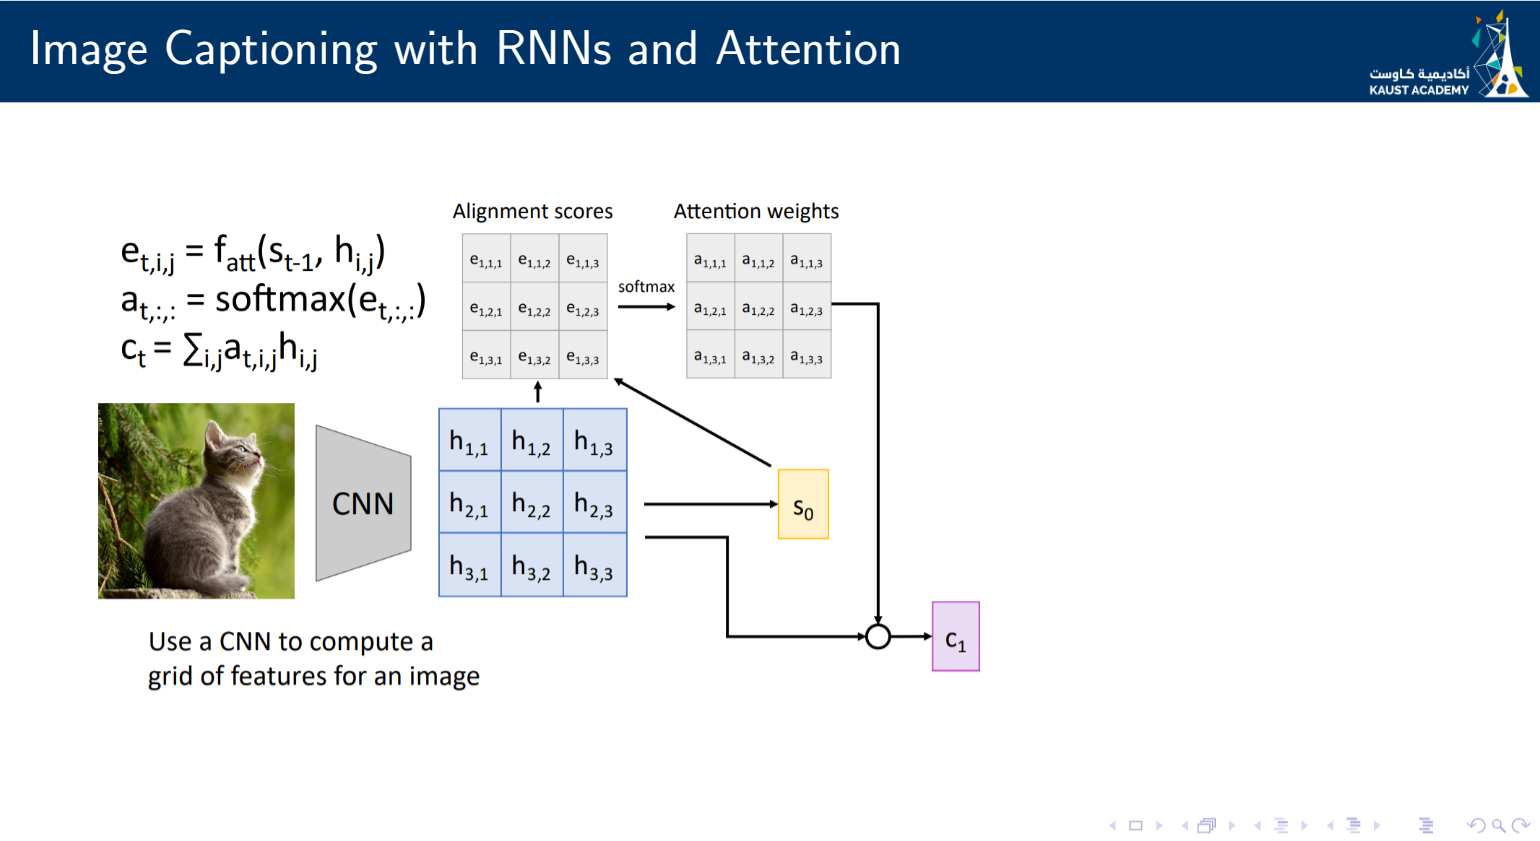

The attention layer will create the context vector at time t,
its inputs:
- image region features from the CNN encoder (🩵)
- hidden state (t-1)

It returns:
- a context vector: the weighted image information
- attention weights: how much the model focused on each image region


In [ ]:
# model takes image regions, hidden state, and returns the context vector
class AdditiveAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()

        #projection layers
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        #fₐₜₜ(sₜ₋₁, hᵢ,ⱼ)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, image_features, hidden_state):
        # image_features: (batch_size, num_regions, encoder_dim)
        # hidden_state:   (batch_size, decoder_dim)

        att1 = self.encoder_att(image_features)
        att2 = self.decoder_att(hidden_state).unsqueeze(1)

        scores = self.full_att(torch.tanh(att1 + att2)).squeeze(2)

        alpha = F.softmax(scores, dim=1)

        context = (image_features * alpha.unsqueeze(2)).sum(dim=1)

        return context, alpha

## Attention-Based LSTM Decoder

The decoder generates one word at a time for the full batch.

At each time step:

1. Embed the current input word.
2. Use attention to focus on image regions and create a context vector.
3. Combine word embedding and visual context as input and feed it to the model.
4. Update the LSTM memory.
5. Predict the next word.

In [ ]:
class AttentionDecoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=256,
        encoder_dim=256,
        decoder_dim=256,
        attention_dim=256,
        dropout_rate=0.3
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.encoder_dim = encoder_dim
        self.decoder_dim = decoder_dim #== hidden_state_size

        self.attention = AdditiveAttention(
            encoder_dim=encoder_dim,
            decoder_dim=decoder_dim,
            attention_dim=attention_dim
        )

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm_cell = nn.LSTMCell(
            input_size=embed_dim + encoder_dim,
            hidden_size=decoder_dim
        )

        #projection layers (from bottle neck/encoding_dim to hidden size)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

        #project the hidden state to the size of the context
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()

        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(decoder_dim, vocab_size)

    def init_hidden_state(self, image_features):
        mean_features = image_features.mean(dim=1) #mean over regions

        h = self.init_h(mean_features)
        c = self.init_c(mean_features)
        return h, c

    def forward(self, image_features, captions_input):
        # image_features:  (batch_size, num_regions, encoder_dim)
        # captions_input:  (batch_size, caption_length)

        #batchsize, sentance length -> batch, sentance length, encoding dim
        caption_length = captions_input.size(1)

        embeddings = self.embedding(captions_input)
        h, c = self.init_hidden_state(image_features)

        predictions_list = []
        alphas_list      = []

        for t in range(caption_length):
            context, alpha = self.attention(image_features, h)

            # make the model choose which parts of the context it wants
            gate = self.sigmoid(self.f_beta(h))
            context = gate * context

            # concatnate word and it's context
            lstm_input = torch.cat(
                [embeddings[:, t, :], context],
                dim=1
            )

            h, c = self.lstm_cell(lstm_input, (h, c))

            output = self.fc(self.dropout(h))

            predictions_list.append(output)
            alphas_list.append(alpha)

        # convert to torch tensors
        predictions = torch.stack(predictions_list, dim=1)
        alphas = torch.stack(alphas_list, dim=1)
        return predictions, alphas

In [ ]:
#Full wrapper model
class ImageCaptioner(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, captions):
        image_features = self.encoder(images)
        predictions, alphas = self.decoder(image_features, captions)

        return predictions, alphas

## Train the Attention Image Captioning Model


In [ ]:
ENCODER_DIM = 256
EMBED_DIM = 256
DECODER_DIM = 256
ATTENTION_DIM = 256

# Create encoder / decoder
encoder = CNNEncoder(encoder_dim=ENCODER_DIM, freeze_cnn=True)
decoder = AttentionDecoder(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    encoder_dim=ENCODER_DIM,
    decoder_dim=DECODER_DIM,
    attention_dim=ATTENTION_DIM,
    dropout_rate=0.3
)

model = ImageCaptioner(encoder, decoder).to(device)
criterion = nn.CrossEntropyLoss(
    ignore_index=vocab[PAD_TOKEN]
)

# btw this wastes a tiny bit of memory, can you spot why ...
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("Number of vocabulary tokens:", len(vocab))

Number of vocabulary tokens: 4641
Encoder and decoder are ready.


In [ ]:
from tqdm import tqdm
def train_caption_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, captions_input, captions_target, _, _ in tqdm(dataloader, desc=f"Epoch {epoch+1:02d} [Train]", leave=False):
        images = images.to(device)
        captions_input = captions_input.to(device)
        captions_target = captions_target.to(device)


        predictions, _ = model(images, captions_input)

        # cross entropy expects a 2d matrix where each row is the generated token probabilities
        # predictions reshaped to (batch_size * caption_length, vocab_size)
        loss = criterion(
            predictions.reshape(-1, predictions.size(-1)),
            captions_target.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        # Prevent gradient exploding, limit the norm of the gradient vector to 5
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_caption_loss(model, dataloader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, captions_input, captions_target, _, _ in tqdm(dataloader, desc="Evaluating", leave=False):
            images = images.to(device)
            captions_input = captions_input.to(device)
            captions_target = captions_target.to(device)

            predictions, _ = model(images, captions_input)

            loss = criterion(
                predictions.reshape(-1, predictions.size(-1)),
                captions_target.reshape(-1)
            )

            total_loss += loss.item()

    return total_loss / len(dataloader)

In [ ]:
EPOCHS = 10
caption_history = []

for epoch in range(EPOCHS):
    train_loss = train_caption_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate_caption_loss(model, val_loader, criterion)

    caption_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    print(f"Epoch {epoch+1:02d} | ", f"Train Loss: {train_loss:.4f} | ", f"Val Loss: {val_loss:.4f}")

Epoch 01 | Train Loss: 4.0518 | Val Loss: 3.3735


Epoch 02 | Train Loss: 3.2618 | Val Loss: 3.0850


Epoch 03 | Train Loss: 2.9917 | Val Loss: 2.9550


Epoch 04 | Train Loss: 2.8142 | Val Loss: 2.8915


Epoch 05 | Train Loss: 2.6792 | Val Loss: 2.8602


Epoch 06 | Train Loss: 2.5659 | Val Loss: 2.8431


Epoch 07 | Train Loss: 2.4690 | Val Loss: 2.8385


Epoch 08 | Train Loss: 2.3850 | Val Loss: 2.8382


Epoch 09 | Train Loss: 2.3127 | Val Loss: 2.8517


Epoch 10 | Train Loss: 2.2434 | Val Loss: 2.8667


,epoch,train_loss,val_loss
0,1,4.051794,3.373540
1,2,3.261817,3.084958
2,3,2.991701,2.954976
3,4,2.814185,2.891498
4,5,2.679150,2.860245
5,6,2.565907,2.843148
6,7,2.468991,2.838493
7,8,2.385031,2.838182
8,9,2.312685,2.851676
9,10,2.243414,2.866745


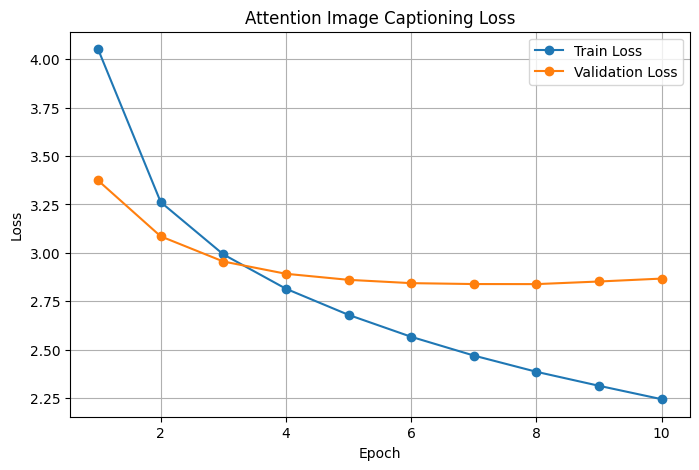

In [ ]:
caption_results = pd.DataFrame(caption_history)
display(caption_results)

plt.figure(figsize=(8, 5))
plt.plot(caption_results["epoch"], caption_results["train_loss"], marker="o", label="Train Loss")
plt.plot(caption_results["epoch"], caption_results["val_loss"], marker="o", label="Validation Loss")
plt.title("Attention Image Captioning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Generate Captions

Now we use the trained encoder and decoder to generate captions.
- Feed the image to our encoder, get nice features
- Initlize the hidden states using the features (🐢)
- Feed the `<SOS>` to the model to start generating
- in each generation step, we compute the context vector, concatnate it with the current word, feed it to the LSTM, use the hidden state to generate the next word
- repeat until the model generates the `<END>` token or it reaches the maximum caption length

In [ ]:
def generate_caption_with_attention(model, image_path, vocab, idx2word, transform, max_len=25):
    model.eval()

    # Load and prepare image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    generated_words = []
    with torch.no_grad():
        image_features = model.encoder(image_tensor)

        decoder = model.decoder
        h, c = decoder.init_hidden_state(image_features)

        # Initialize with the START token
        current_word = torch.tensor(
            [vocab[START_TOKEN]],
            dtype=torch.long,
            device=device
        )

        for _ in range(max_len):
            # same as normal model pipeline
            embedding = decoder.embedding(current_word)
            context, alpha = decoder.attention(image_features, h)

            remember = decoder.f_beta(h)
            context = decoder.sigmoid(remember) * context

            lstm_input = torch.cat([embedding, context], dim=1)
            h, c = decoder.lstm_cell(lstm_input, (h, c))

            scores = decoder.fc(h)
            predicted_id = scores.argmax(dim=1).item()

            # model predicted <EOS>, we're done !
            if predicted_id == vocab[END_TOKEN]:
                break

            generated_words.append(idx2word.get(predicted_id, UNK_TOKEN))

            current_word = torch.tensor(
                [predicted_id],
                dtype=torch.long,
                device=device
            )

    return generated_words

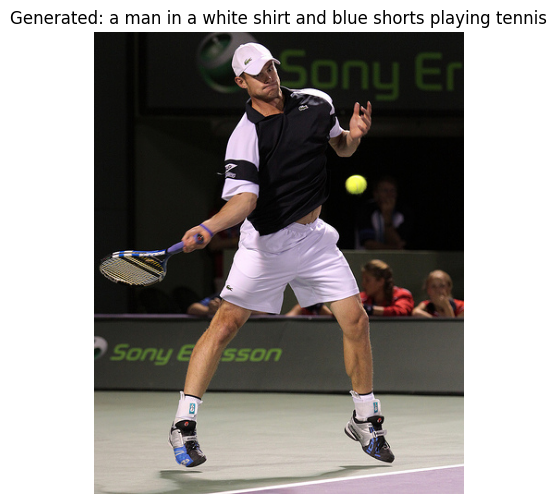

Generated caption:
a man in a white shirt and blue shorts playing tennis

Reference captions:
- A tennis player about to hit the ball .
- A tennis player gets ready to return the ball .
- A tennis player in mid-swing at a match .
- A tennis player wearing a black shirt swings back to hit a yellow ball .
- Man in black and white playing tennis .


In [ ]:
# Generate a caption for one validation image
# pick a random row from val_captions

sample_row = val_captions_df.iloc[np.random.randint(0, len(val_captions_df))]
sample_image_name = sample_row["image"]
sample_image_path = image_paths[sample_image_name]

generated_words = generate_caption_with_attention(
    model=model,
    image_path=sample_image_path,
    vocab=vocab,
    idx2word=idx2word,
    transform=image_transform,
    max_len=25
)

generated_caption = " ".join(generated_words)

reference_captions = val_captions_df[
    val_captions_df["image"] == sample_image_name
]["caption"].tolist()

image = Image.open(sample_image_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Generated: " + generated_caption)
plt.show()

print("Generated caption:")
print(generated_caption)

print("\nReference captions:")
for caption in reference_captions:
    print("-", caption)

### stuff u  can try 👾:
The training loss graph doesn't look too well .. there's a clear generalization gap .. you can try to:
- add weight decay to our optimizer
- increase drop out
- think of other regularization tricks (data augmentations ect., but mainly think of ect.)


Contributed by: Lama Ayash and muhannad